<a href="https://colab.research.google.com/github/CUHK-DH-Lab/YCRG_Cross-Cultural_Analytics/blob/main/Linear_Perspective_Interactive_Notebook_24062025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction
Welcome to this Colab notebook! In this project, we explore how to **automatically detect vanishing points** in images using a combination of **clustering**, **geometry**, and **RANSAC-based model fitting**.

Vanishing points are where parallel lines in 3D space appear to converge in a 2D image — a phenomenon central to many computer vision applications like:

- Camera calibration

- 3D scene reconstruction

- Perspective and layout analysis

This notebook is organized into the following stages: image pre-processing, line detection, intersection analysis, clustering, vanishing point estimation, and visualization.

# Workflow Overview
1.Load and Pre-process the Image

- Read an input image.

- Convert to grayscale.

- Apply Gaussian blur to reduce noise and smooth out small details.

2.Detect Line Segments

- Use LSD (Line Segment Detector) and Hough Transform to extract lines.

- Filter out very short or imprecise segments.

3.Compute Intersections

- For each non-parallel line pair, calculate the intersection point.

- Collect all such intersection points.

4.Cluster Intersection Points

- Use a custom X-means-like algorithm (cluster_xmeans) to group intersections.

- Identify clusters where many lines intersect — likely vanishing point zones.

5.Estimate Vanishing Points

- Treat cluster centers (or intersections) as candidate vanishing points.

- Use SegmentVPModel + RANSAC to evaluate which candidate best explains the observed line directions.

- Select the candidate that minimizes overall angular error.

6.Visualize Results

- Highlight inlier and outlier line segments in different colors.

- Mark the final vanishing point on the image.

- Plot the vanishing point coordinates on a 2D graph.

In [1]:
# Downloads an important module ransac directly from a github repo
!pip -q install git+https://github.com/romack77/ransac.git@173ef6f
!pip -q install opencv-python-headless pillow

  Preparing metadata (setup.py) ... done


In [2]:
#import important packages
import os
import cv2
import shutil
import math
import ransac
import zipfile
import itertools
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Grouping Similar Points Automatically

This code groups (or "clusters") data points that are similar to each other. It starts by guessing one group, then tries more groups to see if it can explain the data better without getting too complicated.

- It uses a method called **k-means** to make groups.
- It decides the best number of groups by balancing accuracy and simplicity using a score called the **Bayesian Information Criterion (BIC)**.
- The code measures how well the groups fit the data and stops when adding more groups doesn’t help.

This helps organize data into meaningful clusters without guessing the number of groups beforehand.


In [10]:
# Main function: tries different numbers of groups to find the best fit
def cluster_xmeans(data_points, max_clusters=100):
    """Clusters data points into an optimal number of groups based on a score."""
    # Start with one group
    num_clusters = 1
    if max_clusters is None:
        max_clusters = math.inf

    # Initial clustering and scoring
    best_labels, best_centers = cluster_kmeans(data_points, num_clusters)
    best_clustering_score = _score_clustering(data_points, best_labels, best_centers)

    # Keep increasing groups until the score stops improving or max is reached
    while num_clusters < len(data_points) and num_clusters <= max_clusters:
        num_clusters += 1
        labels, centers = cluster_kmeans(data_points, num_clusters)
        clustering_score = _score_clustering(data_points, labels, centers)
        if clustering_score < best_clustering_score:
            best_labels = labels
            best_clustering_score = clustering_score
        else:
            break  # Adding more groups didn't improve the result
    return best_labels

# Runs k-means clustering for a set number of groups
def cluster_kmeans(data_points, num_clusters, max_iterations=100, max_accuracy=0.25):
    """Groups points into the given number of clusters using k-means."""
    criteria = (
        cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_MAX_ITER,
        max_iterations,
        max_accuracy)
    _, labels, centers = cv2.kmeans(
        data=data_points, K=num_clusters, bestLabels=None, criteria=criteria,
        attempts=3, flags=cv2.KMEANS_RANDOM_CENTERS)
    return [l[0] for l in labels], centers

# Scores how well the clustering fits data while keeping groups simple
def _score_clustering(data_points, labels, centers):
    """Calculates a score that balances accuracy and simplicity of the clusters."""
    num_obs = data_points.shape[0]
    num_clusters = len(centers)
    total_sse = _get_total_cluster_sse(data_points, labels, centers)
    if total_sse <= 0:
        return 0  # Handles edge case for identical points

    # Lower score means better balance of fit and simplicity
    return num_obs * math.log(total_sse / num_obs) + num_clusters * math.log(num_obs)

# Calculates total error within all groups
def _get_total_cluster_sse(data_points, labels, centers):
    """Adds up the squared errors inside each cluster."""
    center_to_group_data_points = {}
    for i, point in enumerate(data_points):
        group_center = tuple(centers[labels[i]])
        center_to_group_data_points.setdefault(group_center, []).append(point)
    within_group_sse = 0
    for center, group_points in center_to_group_data_points.items():
        within_group_sse += _get_cluster_sse(group_points, center)
    return within_group_sse

# Calculates error inside a single group
def _get_cluster_sse(data_points, center):
    """Sum of squared distances between points and their group center."""
    variance = 0
    for point in data_points:
        variance += _get_distance_between_points(tuple(center), tuple(point)) ** 2
    return variance

# Calculates distance between two points (any number of dimensions)
def _get_distance_between_points(point_a, point_b):
    """Finds how far apart two points are."""
    num_dimensions = len(point_a)
    return math.sqrt(sum([abs(point_a[i] - point_b[i]) ** 2 for i in range(num_dimensions)]))


# Basic Geometry Helpers for Lines and Points

This section provides useful functions to work with lines and points in 2D space, including:

- Finding where lines cross each other (intersections)
- Measuring distances between points and lines
- Calculating angles, slopes, and lengths of lines
- Finding midpoints and average points of groups
- Identifying groups of lines that intersect close together

These tools help analyze shapes and relationships between lines, which is important for detecting vanishing points and understanding image geometry.


In [4]:
#geom tools

def find_all_intersections(lines):
    """Finds intersection points, if any, between all pairs of lines.

    Args:
        lines: List of lines specified as (x1, y1, x2, y2), i.e. two points on the line.

    Returns:
        List of (x, y) intersection points. These are not unique.
    """
    intersection_points = []
    for line_a, line_b in itertools.combinations(lines, 2):
        point = find_intersection(line_a, line_b)
        if point is not None:
            intersection_points.append(point)
    return intersection_points


def find_intersection(line_a, line_b):
    """Finds intersection point between two lines, if any.

    Args:
        line_a: Vector of x1, y1, x2, y2, i.e. two points on the line.
        line_b: Vector of x1, y1, x2, y2, i.e. two points on the line.

    Returns:
        Vector of x, y, the point of intersection. May be None for parallel
        or duplicate lines.
    """
    ax1, ay1, ax2, ay2 = np.array(line_a, dtype=np.float64)
    bx1, by1, bx2, by2 = np.array(line_b, dtype=np.float64)
    denominator = (ax1 - ax2) * (by1 - by2) - (ay1 - ay2) * (bx1 - bx2)
    if denominator == 0:
        return None
    x0 = ((ax1 * ay2 - ay1 * ax2) * (bx1 - bx2) - (
            ax1 - ax2) * (bx1 * by2 - by1 * bx2)) / denominator
    y0 = ((ax1 * ay2 - ay1 * ax2) * (by1 - by2) - (
            ay1 - ay2) * (bx1 * by2 - by1 * bx2)) / denominator
    return x0, y0


def point_to_line_dist(point, line):
    """Finds euclidean distance between a point and a line.

    Args:
        point: Tuple (x, y) point.
        line: Vector of x1, y1, x2, y2, i.e. two points on the line.

    Returns:
        Float, distance.
    """
    px, py = np.array(point, dtype=np.float64)
    x1, y1, x2, y2 = np.array(line, dtype=np.float64)
    nominator = abs((y2 - y1) * px - (x2 - x1) * py + x2 * y1 - y2 * x1)
    return nominator / point_to_point_dist((x1, y1), (x2, y2))


def point_to_point_dist(point_a, point_b):
    """Finds euclidean distance between two points.

    Args:
        point_a: Tuple (x, y) point.
        point_b: Tuple (x, y) point.

    Returns:
        Float, distance.
    """
    x1, y1 = np.array(point_a, dtype=np.float64)
    x2, y2 = np.array(point_b, dtype=np.float64)
    return math.sqrt((y2 - y1) ** 2 + (x2 - x1) ** 2)


def find_nearest_point(point_a, points):
    """Finds the point among a set of points nearest to a given point.

    Args:
        point_a: (x, y) point tuple.
        points: Iterable of (x, y) point tuples.

    Returns:
        Tuple of:
            An (x, y) point tuple.
            Its distance to point_a (float).
    """
    nearest_point = None
    nearest_distance = None
    for point in points:
        dist = point_to_point_dist(point_a, point)
        if nearest_point is None or dist < nearest_distance:
            nearest_distance = dist
            nearest_point = point
    return nearest_point, nearest_distance


def get_midpoint(point_a, point_b):
    """Finds the midpoint of two points.

    Args:
        point_a: Tuple (x, y) point.
        point_b: Tuple (x, y) point.

    Returns:
        Tuple of (x, y) midpoint.
    """
    x1, y1 = point_a
    x2, y2 = point_b
    return (x1 + x2) / 2, (y1 + y2) / 2


def get_line_angle(line):
    """Calculates the angle of a line.

    Args:
        line: Vector of x1, y1, x2, y2, i.e. two points on the line.

    Returns:
        Float, angle in degrees.
    """
    x1, y1, x2, y2 = np.array(line, dtype=np.float64)
    radians = np.arctan2(y2 - y1, x2 - x1)
    return math.degrees(radians) % 360


def get_line_slope(line):
    """Calculates the slope of a line.

    Args:
        line: Vector of x1, y1, x2, y2, i.e. two points on the line.

    Returns:
        Float, slope value.

    Raises:
        ZeroDivisionError, if slope is undefined (vertical lines).
    """
    x1, y1, x2, y2 = np.array(line, dtype=np.float64)
    denom = x2 - x1
    if denom == 0:
        raise ZeroDivisionError
    return (y2 - y1) / denom


def get_line_length(line):
    """Calculates the length of a line segment.

    Args:
        line: Vector of x1, y1, x2, y2, i.e. two points on the line.

    Returns:
        Float, line length.
    """
    return point_to_point_dist((line[0], line[1]), (line[2], line[3]))


def find_bounding_points(points):
    """Finds the minimum points that bound the set of points.

    In 2d, this is the lower left and upper right corners of
    a rectangle that contains all the given points. Overlap is
    allowed.

    Args:
        points: List of points.

    Returns:
        Tuple of min and max bounding points tuples.
    """
    if not points:
        return None, None
    min_bounding_point = list(points[0])
    max_bounding_point = list(points[0])
    for point in points:
        for i, coord in enumerate(point):
            min_bounding_point[i] = min(min_bounding_point[i], coord)
            max_bounding_point[i] = max(max_bounding_point[i], coord)
    return min_bounding_point, max_bounding_point


def find_point_on_rect_border(rect, angle):
    """Finds the point on the border at the given angle from center.

    Args:
        rect: Tuple of two points, the lower left and upper right
            corners of the rectangle.
        angle: Angle, in degrees.

    Returns:
        A point tuple on the rectangle's border.
    """
    # Grow the rectangle into a square, and find the border point on that,
    # since it's easier.
    width = abs(rect[1][0] - rect[0][0])
    height = abs(rect[1][1] - rect[0][1])
    square_size = max(width, height)
    square = [rect[0], (rect[0][0] + square_size, rect[0][1] + square_size)]
    border_x, border_y = _find_point_on_square_border(square, angle)
    # Scale the result to find the corresponding point on the original rectangle.
    border_x = border_x * (width / square_size)
    border_y = border_y * (height / square_size)
    return int(round(border_x)), int(round(border_y))


def _find_point_on_square_border(square, angle):
    """Finds the point on the border at the given angle from center.

    Args:
        square: Tuple of two points, the lower left and upper right
            corners of the square.
        angle: Angle, in degrees.

    Returns:
        A point tuple on the square's border.
    """
    angle = math.radians(angle)
    width = abs(square[1][0] - square[0][0])
    height = abs(square[1][1] - square[0][1])
    assert width == height
    center_x = square[0][0] + width / 2
    center_y = square[0][1] + height / 2
    abs_cos_angle = abs(math.cos(angle))
    abs_sin_angle = abs(math.sin(angle))
    if width / 2 * abs_sin_angle <= height / 2 * abs_cos_angle:
        magnitude = width / 2 / abs_cos_angle
    else:
        magnitude = height / 2 / abs_sin_angle
    border_x = center_x + math.cos(angle) * magnitude
    border_y = center_y + math.sin(angle) * magnitude
    return int(round(border_x)), int(round(border_y))


def find_point_cluster_average(points):
    """Finds the average of a set of points.

    This is a center of mass style average.

    Args:
        points: List of point tuples.

    Returns:
        Point tuple.
    """
    if len(points) == 0:
        return None
    x_sum = np.float64(0)
    y_sum = np.float64(0)
    for x, y in points:
        x_sum += x
        y_sum += y
    return x_sum / len(points), y_sum / len(points)


def get_biggest_intersection(lines, intersection_threshold=3):
    """Finds point with the most lines intersecting.

    Intersections can be considered loosely (within a radius) depending
    on the threshold parameter.

    Args:
        lines: Iterable of lines tuples in (x1, y1, x2, y2) format.
        intersection_threshold: Maximum distance between a line and
            an intersection point for it to be considered a member of
            that intersection.

    Returns:
        Tuple of intersection point, array of lines intersecting there.
        May return (None, None) if no intersections are found.
    """

    intersection_to_lines = _group_lines_by_intersections(
        list(lines), intersection_threshold=intersection_threshold)
    if len(intersection_to_lines) == 0:
        return None, None
    intersection_point, intersection_lines = sorted(
        intersection_to_lines.items(), key=lambda t: len(t[1]))[-1]
    return intersection_point, intersection_lines


def _group_lines_by_intersections(lines, intersection_threshold=3):
    """Group lines according to their intersection points, within some tolerance.

    Args:
        lines: Iterable of lines tuples in (x1, y1, x2, y2) format.
        intersection_threshold: Maximum distance between a line and
            an intersection point for it to be considered a member of
            that intersection.

    Returns:
        Dict of intersection point to set of lines considered to intersect there.
        A line may belong to 0-n intersection points.
    """
    intersection_points = list(set(find_all_intersections(lines)))
    intersection_to_lines = {}
    for point in intersection_points:
        intersection_to_lines[point] = []
        for line in lines:
            if point_to_line_dist(point, line) < intersection_threshold:
                intersection_to_lines[point].append(line)
    return intersection_to_lines


def find_largest_intersection_cluster(lines):
    """Finds the largest cluster of nearby line intersections.

    Args:
        lines: List of lines specified as (x1, y1, x2, y2), i.e. two points on the line.

    Returns:
        List of intersection points, i.e. (x, y) tuples.
    """
    intersection_points = np.float32(np.asarray(find_all_intersections(lines)))
    if len(intersection_points) == 0:
        return []
    elif len(intersection_points) == 1:
        return intersection_points
    labels = cluster_xmeans(intersection_points, max_clusters=10)
    label_to_points = {}
    for i, label in enumerate(labels):
        label_to_points.setdefault(label, []).append(intersection_points[i])
    point_clusters = sorted(label_to_points.values(), key=lambda points: len(points))
    return point_clusters[-1]


# Line Detection Tools

These functions provide different ways to detect lines and edges in images, useful for shape and structure analysis:

- **Edge enhancement:** Prepares images by smoothing and converting to grayscale.
- **LSD (Line Segment Detector):** Detects line segments using OpenCV's advanced LSD algorithm.
- **Hough Lines:** Detects lines by accumulating votes in parameter space, good for longer lines.
- **Canny Edge Detection:** Finds edges by gradient changes, adaptive to image intensity.

All methods return line endpoints as (x1, y1, x2, y2) tuples or edge images.

In [5]:
#line_detector

def enhance_edges(image):
    """Pre-processing step to enhance edges.

    Args:
        image: OpenCV image.

    Returns:
        Image, filtered for edge detection.
    """
    working_image = image.copy()
    working_image = cv2.cvtColor(working_image, cv2.COLOR_BGR2GRAY)
    # Blur away fine details.
    working_image = cv2.GaussianBlur(working_image, (5, 5), 0)
    return working_image


def lsd_lines(source_image, min_line_length=0.0375, max_line_length=1, min_precision=0):
    """LSD algorithm for line detection.

    Args:
        source_image: An OpenCV Image.
        min_line_length: Minimum line size. Specified as a percentage of the
            source image diagonal (0-1).
        max_line_length: Maximum line size. Specified as a percentage of the
            source image diagonal (0-1).
        min_precision: Minimum precision of detections.

    Returns:
        Array of line endpoints tuples (x1, y1, x2, y2).
    """
    height, width = source_image.shape[:2]
    diagonal = math.sqrt(height ** 2 + width ** 2)
    min_line_length = min_line_length * diagonal
    max_line_length = max_line_length * diagonal

    detector = cv2.createLineSegmentDetector(cv2.LSD_REFINE_ADV)
    lines, rect_widths, precisions, false_alarms = detector.detect(source_image)
    line_lengths = [get_line_length(l[0]) for l in lines]
    return [l[0] for (i, l) in enumerate(lines)
            if max_line_length > line_lengths[i] > min_line_length and
            precisions[i] > min_precision]


def hough_lines(source_image, min_points=0.075, min_line_length=0.2, max_line_gap=0.2):
    """Hough line detection.

    Args:
        source_image: An OpenCV Image.
        min_points: Float, minimum number of points that must be detected on a line.
            Specified as a percentage of the source image diagonal (0-1).
        min_line_length: Minimum line size. Specified as a percentage of the
            source image diagonal (0-1).
        max_line_gap: Maximum gap between segments of the same line. Specified as
            a percentage of the source image diagonal (0-1).
    Returns:
        Array of line endpoints tuples (x1, y1, x2, y2).
    """
    height, width = source_image.shape[:2]
    size = math.sqrt(height ** 2 + width ** 2)
    lines = cv2.HoughLinesP(
        source_image,
        1,
        np.pi / 180,
        math.ceil(min_points * size),
        minLineLength=math.ceil(min_line_length * size),
        maxLineGap=math.ceil(max_line_gap * size))
    return [l[0] for l in lines] if lines is not None else []


def canny_edges(image, thresholding_sigma=0.33):
    """Detects edges in an image.

    Uses Canny edge detection method. Bases thresholding on
    image statistics combined with the provided sigma.

    Args:
        image: An OpenCV Image.
        thresholding_sigma: Float. Higher values will detect more edges.

    Returns:
        Image with edges marked.
    """
    # compute the median of the single channel pixel intensities
    v = np.median(image)
    # apply automatic Canny edge detection using the computed median
    lower = int(max(0, (1.0 - thresholding_sigma) * v))
    upper = int(min(255, (1.0 + thresholding_sigma) * v))
    edged_image = cv2.Canny(image, lower, upper)
    return edged_image

# Detecting the Vanishing Point from Lines in an Image

This part of the code is designed to find the "vanishing point" in an image, which is the spot where many lines appear to converge, such as the point where parallel lines like roads or railway tracks seem to meet far away.

Here's what it does in simple terms:

- It takes a collection of straight lines detected in the image.
- It calculates where these lines intersect each other to find possible candidate points.
- For each candidate point, it measures how well that point fits as a vanishing point by looking at the distance between the lines and a line drawn from the midpoint of each segment to the candidate point.
- It picks the candidate point with the smallest overall error as the best vanishing point.
- This vanishing point helps to understand the perspective and depth in the scene, which is useful in many applications like 3D modeling, augmented reality, and image understanding.

This code cleverly figures out the most likely spot in an image where all the lines seem to come together, helping machines to interpret visual perspective like humans do.


In [6]:
class SegmentVPModel(ransac.Model):
    """Fits a vanishing point to a set of lines.

    The error measure is segment_midpoint_vp_error().
    """

    def fit(self, data):
        best_vp_point = choose_best_vp_by_max_error(data)
        if best_vp_point is None:
            raise ransac.DegenerateModelException()
        return best_vp_point

    def predict(self, xs, fit):
        return None

    def get_residuals(self, data, best_vp_point):
        residuals = np.array([
            segment_midpoint_vp_error(segment, best_vp_point)
            for segment in data])
        return residuals


def choose_best_vp_by_max_error(lines):
    """Finds the vanishing point that minimizes error among lines.

    Candidates vps are intersections of the lines.
    The error measure is segment_midpoint_vp_error().

    Returns:
        Vanishing point tuple, or None if detection fails.
    """
    intersections = find_all_intersections(lines)
    best_vp = None
    best_vp_error = None
    for point in intersections:
        error = max([segment_midpoint_vp_error(l, point) for l in lines])
        if best_vp is None or error < best_vp_error:
            best_vp = point
            best_vp_error = error
    return best_vp


def segment_midpoint_vp_error(segment, vp):
    """Calculates an error term for a segment's assignment to a vanishing point.

    This uses the distance from a segment endpoint to a line passing through
    the vanishing point and the segment's midpoint.

    Args:
        segment: Segment tuple in (x1, y1, x2, y2) format.
        vp: Tuple of vanishing point, i.e. (vx, vy).

    Returns:
        Float, error amount.
    """
    sx1, sy1, sx2, sy2 = segment
    vx, vy = vp
    cx, cy = get_midpoint((sx1, sy1), (sx2, sy2))
    vp_midpoint_line = (cx, cy, vx, vy)
    return point_to_line_dist((sx1, sy1), vp_midpoint_line)

# Finding Points Where Lines Meet in a Picture

This code helps find spots in a photo where many lines seem to come together, like roads or rails that look like they meet far away.

---

- First, it finds all the straight lines in the image.
- Then, it uses smart methods to group these lines and guess where they all meet.
- It can use two different ways to find these meeting points.
- Finally, it tells you where those points are and which lines belong to each point.

---

This helps us understand the depth and direction in a flat photo by spotting where lines come together in the distance.


In [7]:
def find_vanishing_points_in_image(
        image,
        line_detection_options=None,
        ransac_options=None,
        x_ransac_options=None):
    """Estimates the vanishing points in an image.

    There are no accuracy guarantees on the number of vanishing points
    returned (it may be under or over ground truth, or even 0), or their
    estimated locations.

    Args:
        image: OpenCV image.
        line_detection_options: LineDetectionOptions instance. If None,
            a default instance is used.
        ransac_options: RansacOptions instance. If None, a default instance
            is used.
        x_ransac_options: An XRansacOptions instance. If supplied, X-RANSAC
            is used to choose VP models instead of J-linkage.

    Returns:
        Tuple of:
            1) Dict of vanishing point tuple to line set.
            2) List of lines that were rejected by all models, if any.
        Both items may be empty if a valid model was never found.
    """
    if line_detection_options is None:
        line_detection_options = LineDetectionOptions()
    if ransac_options is None:
        ransac_options = RansacOptions()

    lines = _detect_lines(image, line_detection_options)

    if x_ransac_options is None:
        return _find_vanishing_points_j_linkage(lines, ransac_options)
    else:
        image_height, image_width, _ = image.shape
        image_diagonal_length = round(
            math.sqrt(image_height ** 2 + image_width ** 2))
        return _find_vanishing_points_x_ransac(
            lines, ransac_options, x_ransac_options, image_diagonal_length)


class LineDetectionOptions(object):

    def __init__(self, min_edge_length=0.055, min_edge_precision=0.05):
        # These values are in terms of a ratio of the pixels in the
        # diagonal of the image.
        self.min_edge_length = min_edge_length
        self.min_edge_precision = min_edge_precision


class RansacOptions(object):
    """Stores options for the X-RANSAC extension."""

    def __init__(
            self,
            model=None,
            num_sample_points=2,
            inlier_threshold=3,
            min_inliers=4,
            outlier_rate=0.73,
            desired_success_rate=0.999,
            max_iterations=10000,
            random_seed=0):
        if model is None:
            model = SegmentVPModel()
        self.model = model
        self.num_sample_points = num_sample_points
        self.inlier_threshold = inlier_threshold
        self.min_inliers = min_inliers
        self.outlier_rate = outlier_rate
        self.desired_success_rate = desired_success_rate
        self.max_iterations = max_iterations
        self.random_seed = random_seed


class XRansacOptions(object):
    """Stores options for the X-RANSAC extension."""

    def __init__(
            self,
            min_peak_samples=10,
            residual_histogram_num_bins=25,
            min_prominence=5):
        self.min_peak_samples = min_peak_samples
        self.residual_histogram_num_bins = residual_histogram_num_bins
        self.min_prominence = min_prominence


def _detect_lines(image, options):
    """Finds lines in an image.

    Args:
        image: OpenCV image.
        options: LineDetectionOptions instance.

    Returns:
        List of lines in [x1, y1, x2, y2] format.
    """
    image = image.copy()
    image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    lines = lsd_lines(
        image,
        min_line_length=options.min_edge_length,
        min_precision=options.min_edge_precision)
    return lines

def _find_vanishing_points_x_ransac(
        lines, ransac_options, x_ransac_options):
    """Runs XRansac on a given line set to detect vanishing points.

    Args:
        lines: List of lines specified as (x1, y1, x2, y2),
            i.e. two points on the line.
        ransac_options: RansacOptions instance.
        x_ransac_options: XRansacOptions instance.

    Returns:
        Tuple of:
            1) Dict of vanishing point tuple to line set.
            2) List of lines that were rejected by all models, if any.
        Both items may be empty if a valid model was never found.
    """
    stop_iterations = ransac.calculate_xransac_iterations(
        ransac_options.num_sample_points,
        ransac_options.outlier_rate,
        ransac_options.desired_success_rate,
        min_peak_samples=x_ransac_options.min_peak_samples)
    ransac_inst = ransac.XRansac(
        ransac_options.model,
        num_sample_points=ransac_options.num_sample_points,
        min_inliers=ransac_options.min_inliers,
        inlier_threshold=ransac_options.inlier_threshold,
        stop_iterations=stop_iterations,
        random_seed=ransac_options.random_seed,
        residual_histogram_num_bins=x_ransac_options.residual_histogram_num_bins,
        min_prominence=x_ransac_options.min_prominence)
    results = ransac_inst.run(np.array(lines))
    if not results or len(results.get_model_results()) == 0:
        return {}, lines
    vp_to_inliers = {r.fit: r.inliers for r in results.get_model_results()}
    return vp_to_inliers, results.get_global_outliers()


def _find_vanishing_points_j_linkage(lines, options):
    """Runs J-linkage on a given line set to detect vanishing points.

    Args:
        lines: List of lines specified as (x1, y1, x2, y2),
            i.e. two points on the line.
        options: RansacOptions instance.

    Returns:
        Tuple of:
            1) Dict of vanishing point tuple to line set.
            2) List of lines that were rejected by all models, if any.
        Both items may be empty if a valid model was never found.
    """
    stop_iterations = ransac.calculate_ransac_iterations(
        options.num_sample_points,
        options.outlier_rate,
        options.desired_success_rate)
    j_link = ransac.JLinkage(
        options.model,
        num_sample_points=options.num_sample_points,
        min_inliers=options.min_inliers,
        inlier_threshold=options.inlier_threshold,
        stop_iterations=stop_iterations,
        random_seed=options.random_seed)
    results = j_link.run(np.array(lines))
    if not results or len(results.get_model_results()) == 0:
        return {}, lines
    vp_to_inliers = {r.fit: r.inliers for r in results.get_model_results()}
    return vp_to_inliers, results.get_global_outliers()


# Detect and Show Where Lines Meet in the Image

This part of the code loads a photo, finds where lines in the image meet (vanishing points), and then draws those lines and points on top of the image.

---

### What’s happening:
- The image is loaded from your computer.
- Vanishing point detection is run on it to find spots where many lines seem to converge.
- Lines that go to vanishing points are drawn in green.
- Lines that don’t fit are drawn in red.
- Each vanishing point is shown as a blue circle.

---

This makes it easy to **see depth and perspective** in the image by showing how lines guide our eyes to certain points.

**NOTE**: If you get an error for not enough samples, that means there is no vanishing point detected by the program.

In [8]:
try:

  # Set input image path (change as needed to match your uploaded file)
  input_path = '2.jpg'

  # Read the image
  image = cv2.imread(input_path)
  if image is None:
      raise ValueError(f"Failed to read image from {input_path}")

  # Run vanishing point detection
  vp_to_inliers, rejected = find_vanishing_points_in_image(image)

  # Draw annotations function
  def draw_annotations(image, vp_to_inliers, rejected,
                       inlier_color=(0, 255, 0),
                       outlier_color=(0, 0, 255),
                       vp_color=(255, 0, 0),
                       inlier_thickness=2,
                       outlier_thickness=1,
                       vp_radius=20,
                       vp_thickness=4):

      height, width = image.shape[:2]

      def is_on_edge(x, y):
          return x <= 0 or x >= width - 1 or y <= 0 or y >= height - 1

      for vp, lines in vp_to_inliers.items():
          for x1, y1, x2, y2 in lines:
              if any(is_on_edge(int(x), int(y)) for x, y in [(x1, y1), (x2, y2)]):
                  continue  # Skip if either endpoint is on the edge
              cv2.line(image, (int(x1), int(y1)), (int(x2), int(y2)), inlier_color, inlier_thickness)

      for x1, y1, x2, y2 in rejected:
          if any(is_on_edge(int(x), int(y)) for x, y in [(x1, y1), (x2, y2)]):
              continue  # Skip if either endpoint is on the edge
          cv2.line(image, (int(x1), int(y1)), (int(x2), int(y2)), outlier_color, outlier_thickness)

      for x, y in vp_to_inliers.keys():
          if np.isfinite(x) and np.isfinite(y):
              cv2.circle(image, (int(round(x)), int(round(y))), vp_radius, vp_color, vp_thickness)

      return image

  # Annotate and show the image inline
  annotated = draw_annotations(image.copy(), vp_to_inliers, rejected)

  plt.figure(figsize=(10, 8))
  plt.axis('off')
  plt.title("Vanishing Point Detection")
  plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
  plt.show()

  print("\nThis is a Linear Image")

except ValueError:
  print("This is a non-Linear Image")

This is a non-Linear Image


NameError: name 'vp_to_inliers' is not defined

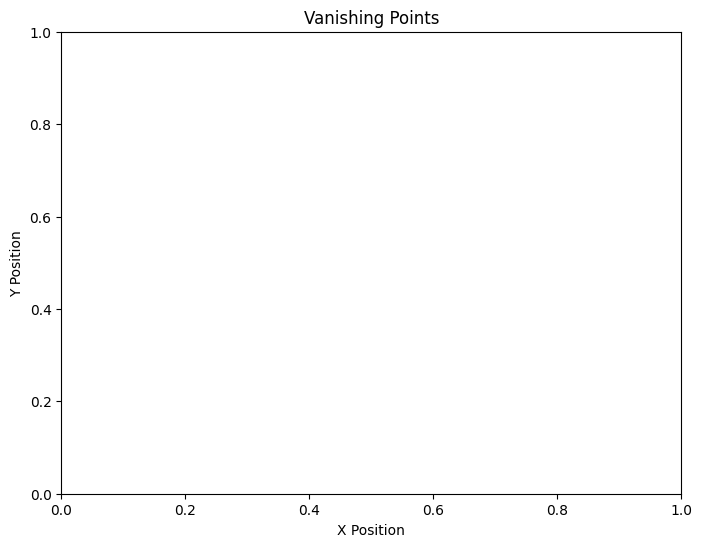

In [9]:
# Plot vanishing points on a 2D graph with labels

# Create a new plot
plt.figure(figsize=(8, 6))
plt.title("Vanishing Points")
plt.xlabel("X Position")
plt.ylabel("Y Position")

# Plot and label each vanishing point
for idx, (x, y) in enumerate(vp_to_inliers.keys(), start=1):
    if np.isfinite(x) and np.isfinite(y):
        plt.plot(x, y, 'bo')
        plt.text(x + 10, y, f'VP{idx}: ({int(x)}, {int(y)})', fontsize=9, color='black')

plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
"""

When you run this cell, you have the option to upload a .zip file, the zip file must contain images only such as ".jpg", ".jpeg", ".png", ".bmp", ".tif" or ".tiff".
Each image in the zip file will be classsified as linear or non linear and save them in a dictionary called results_dict.

  WARNING ---> you can only upload '.zip' file and the file must contain only images. Colab does not support direct folder uploads and passing any other files will result in an error.

"""


KEEP = {".config", "sample_data",".ipynb_checkpoints"}

for item in os.listdir("/content"):
    if item not in KEEP:
        path = os.path.join("/content", item)
        try:
            if os.path.isfile(path) or os.path.islink(path):
                os.remove(path)
            else:
                shutil.rmtree(path)
        except Exception as e:
            print(f"Could not remove {path}: {e}")

uploaded = files.upload()
zip_name = next(iter(uploaded))
extract_root = f"/content/"
os.makedirs(extract_root, exist_ok=True)


with zipfile.ZipFile(zip_name) as z:
    z.extractall(extract_root)

valid_exts = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")
folder_path = f"/content/{zip_name.replace('.zip','')}"
img_paths = [f for f in os.listdir(folder_path) if f.lower().endswith(valid_exts)]


if not img_paths:
    raise FileNotFoundError("No valid image files found in the uploaded zip.")

results_dict = {}

for img_path in img_paths:
    img_name = os.path.basename(img_path)
    img = cv2.imread(folder_path+"/"+img_path)
    if img is None:
        print(f"Warning: Could not read {img_name}")
        continue
    try:
      vp_to_inliers, rejected = find_vanishing_points_in_image(img)
      label = "Linear"
    except:
      label = "Non-Linear"
    results_dict[img_name] = label


In [ ]:
# Map each image to its classified label of linear or non linear in an interactive manner
#    Green = Linear
#    Red   = Non-Linear

df = pd.DataFrame(list(results_dict.items()), columns=["Image", "Classification"])
df.style.map(lambda val: 'color: green' if val == 'Linear' else 'color: red', subset=['Classification'])

# Code References

- The main code is from [Romack77 vp-tool github repository](https://github.com/romack77/vp-toolbox?tab=readme-ov-file) which includes the whole working of the detection of converging lines and vanishing points.
- The Ransac model used is from [Romack77 ransac robust model for fitting noisy data](https://github.com/romack77/ransac) which is used to counter any outliers in data that should be ignored in model fitting.


# Theory References
- **For the multi-model RANSAC variant:**

  Zhang, W., KoseckÃ¡, J.: [Nonparametric estimation of multiple structures with outliers.](Nonparametric estimation of multiple structures with outliers.) In: Vidal, R., Heyden, A., Ma, Y. (eds.) WDV 2006. LNCS, vol. 4358, pp. 60-74. Springer, Heidelberg (2006)

- **For the Segment-VP consistency measure:**

  H. Wildenauer and M. Vincze. [Vanishing point detection in complex man-made worlds](https://ieeexplore.ieee.org/abstract/document/4362845). In ICIAP, 2007.

- **For an empirical comparison of several approaches:**

  Kluger F., Ackermann H., Yang M.Y., Rosenhahn B. (2017) [Deep Learning for Vanishing Point Detection Using an Inverse Gnomonic Projection.](https://link.springer.com/chapter/10.1007/978-3-319-66709-6_2) In: Roth V., Vetter T. (eds) Pattern Recognition. GCPR 2017. Lecture Notes in Computer Science, vol 10496. Springer, Cham

- **For the J-linkage variant:**

  Toldo, R., & Fusiello, A. (2008, October). [Robust multiple structures estimation with j-linkage](https://link.springer.com/chapter/10.1007/978-3-540-88682-2_41). In European conference on computer vision (pp. 537-547). Springer, Berlin, Heidelberg.

- **A very similar approach:**

  Tardif, J. P. (2009, September). [Non-iterative approach for fast and accurate vanishing point detection.](https://ieeexplore.ieee.org/abstract/document/5459328) In Computer Vision, 2009 IEEE 12th International Conference on (pp. 1250-1257). IEEE.